# Convert Astra to Bmad

In [1]:
# Useful for debugging
%load_ext autoreload
%autoreload 2

%pylab --no-import-all inline
%config InlineBackend.figure_format = 'retina'

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
from astra import Astra
from distgen import Generator

from astra.interfaces.bmad import bmad_cavity, bmad_solenoid

import os


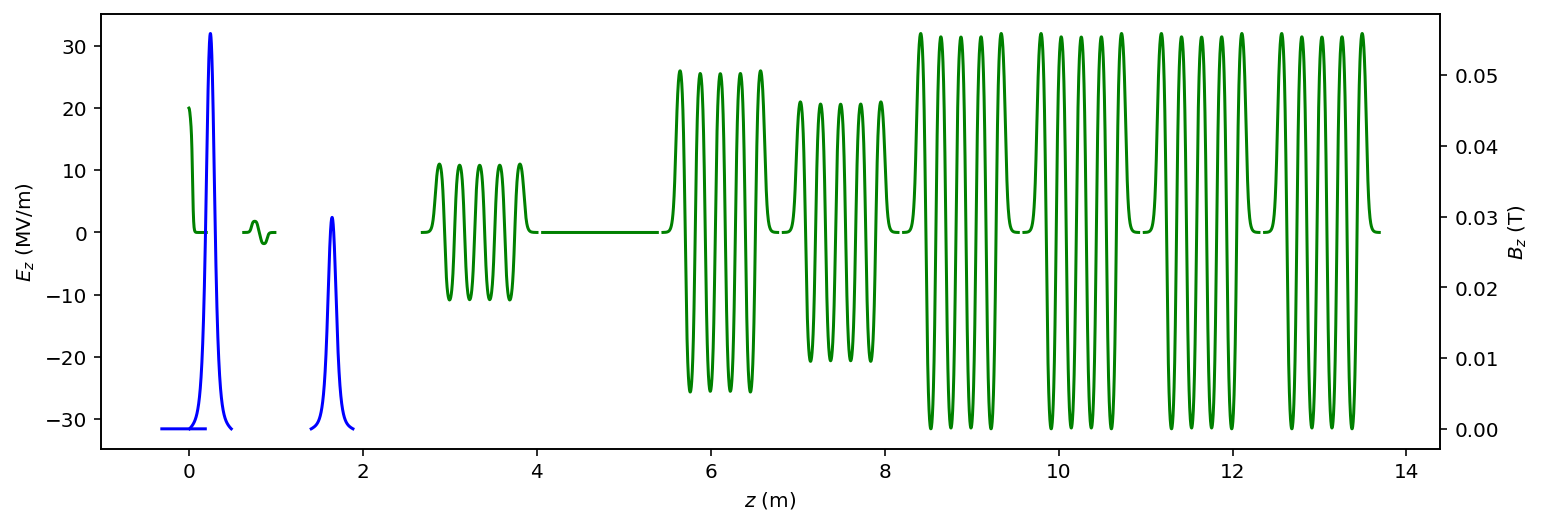

In [6]:
A = Astra('$LCLS_LATTICE/astra/models/sc_inj/v1/astra.in')
A.load_fieldmaps(search_paths=[os.path.expandvars('$LCLS_LATTICE/astra/fieldmaps')])
A.plot()

In [7]:
A.input['solenoid']

{'file_bfield(1)': 'realbucking.dat',
 'file_bfield(2)': 'newSOL.dat',
 'file_bfield(3)': 'newSOL.dat',
 'lbfield': True,
 'maxb(1)': 0,
 'maxb(2)': 0.0559,
 'maxb(3)': 0.0299,
 's_higher_order(1)': True,
 's_higher_order(2)': True,
 's_higher_order(3)': True,
 's_pos(1)': -0.062,
 's_pos(2)': 0.24653,
 's_pos(3)': 1.64581,
 's_smooth(1)': 10,
 's_smooth(2)': 10,
 's_smooth(3)': 10,
 's_xoff(1)': 0,
 's_xoff(2)': 0,
 's_xoff(3)': 0,
 's_yoff(1)': 0,
 's_yoff(2)': 0,
 's_yoff(3)': 0}

In [8]:
from astra.fieldmaps import find_fieldmap_ixlist
from pmd_beamphysics.fields.analysis import accelerating_voltage_and_phase

# Gun

In [9]:
gun = bmad_cavity(A, 1, name='RFGUNB', keyword='apex_gun', superimpose=False)

print(gun)

RFGUNB: apex_gun,
  rf_frequency = 187000000.0, voltage = 759250.2223014082, phi0 = 0.02361111111111111


# Solenoids

In [13]:
A.input['solenoid']['s_pos(2)']

0.24653

In [14]:
sols = [
#    bmad_solenoid(A, 1, name='SOL1BKB', keyword='lcls2_bucking_solenoid', ele_origin='beginning', ref_offset = -0.1),
    bmad_solenoid(A, 2, name='SOL1B', keyword='lcls2_solenoid', ele_origin='beginning', ref_offset = 0),
    bmad_solenoid(A, 3, name='SOL2B', keyword='lcls2_solenoid', ele_origin='beginning', ref_offset = 0)
]
for line in sols:
    print(line)

SOL1B: lcls2_solenoid,
  ! B_max = 0.0559 T,
  ! \int B dL = B_max * 0.12896517423475376 m,
  ! \int B^2 dL = B_max^2 * 0.08623994625099243 m,
  ! Hard edge L = 0.19285745050205194 m,
  ! Hard edge B = 0.03738073494674779 T,
  bs_field = 0.0559,
  superimpose, ele_origin = beginning, offset = 0.24653
SOL2B: lcls2_solenoid,
  ! B_max = 0.0299 T,
  ! \int B dL = B_max * 0.12896517423475376 m,
  ! \int B^2 dL = B_max^2 * 0.08623994625099243 m,
  ! Hard edge L = 0.19285745050205194 m,
  ! Hard edge B = 0.019994346599423236 T,
  bs_field = 0.0299,
  superimpose, ele_origin = beginning, offset = 1.64581


# Cavities

In [21]:
cav_names = [f'CAVL01{i}' for i in range(1,9)]
cav_names

['CAVL011',
 'CAVL012',
 'CAVL013',
 'CAVL014',
 'CAVL015',
 'CAVL016',
 'CAVL017',
 'CAVL018']

In [22]:
buncher = bmad_cavity(A, 2, name='BUN1B', keyword='apex_buncher_1300MHz')

cavs = [buncher] + [bmad_cavity(A, ix, name=name, keyword='cavity9_1300MHz') for ix, name in zip(range(3,11), cav_names)]

for line in cavs:
    print(line)

BUN1B: apex_buncher_1300MHz,
  rf_frequency = 1300000000.0, voltage = 210652.95554408507, phi0 = -0.24583333333333332,
  superimpose, ele_origin = center, offset = 0.809116
CAVL011: cavity9_1300MHz,
  rf_frequency = 1300000000.0, voltage = 5988735.717353206, phi0 = 0.022222222222222223,
  superimpose, ele_origin = center, offset = 3.3428
CAVL012: cavity9_1300MHz,
  rf_frequency = 1300000000.0, voltage = 0.0, phi0 = -0.025,
  superimpose, ele_origin = center, offset = 4.7264
CAVL013: cavity9_1300MHz,
  rf_frequency = 1300000000.0, voltage = 14155193.513743944, phi0 = -0.05555555555555555,
  superimpose, ele_origin = center, offset = 6.11
CAVL014: cavity9_1300MHz,
  rf_frequency = 1300000000.0, voltage = 11433040.914947031, phi0 = 0.07222222222222222,
  superimpose, ele_origin = center, offset = 7.4936
CAVL015: cavity9_1300MHz,
  rf_frequency = 1300000000.0, voltage = 17421776.632300235, phi0 = 0.0,
  superimpose, ele_origin = center, offset = 8.8772
CAVL016: cavity9_1300MHz,
  rf_freque